<span style='font-size:50px; font-weight:bold;'>EDA & Visualization</span>

---

In [23]:
# import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('data/IMDb_movies_cleaned.csv')
df.head()

,title,genres,description,keywords,release_date,duration,content_rating,director,star_1,star_2,...,user_reviews,critic_reviews,watchlist_count,gross,budget,movie_url,category,currency_type,gross_usd,budget_usd
0,Kate & Leopold,Comedy|Fantasy|Romance,An English Duke from 1876 is inadvertently dra...,"time travel,time travel romance,female time tr...",2001-12-25,118,PG-13,James Mangold,Meg Ryan,Hugh Jackman,...,376.0,92.0,66600.0,"$76,019,048","$48,000,000 (estimated)",https://www.imdb.com/title/tt0035423/,Mid Rated,$,76019048.0,48000000.0
1,Ko to tamo peva,Adventure|Comedy|Drama,"It&apos;s April 5, 1941, somewhere in Serbia. ...","road trip,sex scene,female nudity,year 1941,yu...",1980-06-30,86,Unknown,Slobodan Sijan,Pavle Vuisic,Dragan Nikolic,...,42.0,11.0,12200.0,NaN,NaN,https://www.imdb.com/title/tt0076276/,Top Rated|Old Movies,NaN,NaN,NaN
2,Cannibal Holocaust,Adventure|Horror,An anthropologist ventures into the Amazon rai...,"rape,animal cruelty,gang rape,actual animal ki...",1985-06-21,95,Unrated,Ruggero Deodato,Robert Kerman,Francesca Ciardi,...,685.0,208.0,66800.0,$477,"$100,000 (estimated)",https://www.imdb.com/title/tt0078935/,Old Movies,$,477.0,100000.0
3,Saturn 3,Adventure|Horror|Sci-Fi,Two lovers stationed at a remote base in the a...,"psychopath,infatuation,robot sci fi,male rear ...",1980-02-15,88,R,Stanley Donen,Farrah Fawcett,Kirk Douglas,...,165.0,63.0,9300.0,"$9,000,000","£10,000,000 (estimated)",https://www.imdb.com/title/tt0079285/,Old Movies,£,9000000.0,12500000.0
4,Moskva slezam ne verit,Comedy|Drama|Romance,Three young provincial women come to Moscow in...,"city name in title,group of friends,soviet uni...",1980-02-11,150,PG,Vladimir Menshov,Vera Alentova,Aleksey Batalov,...,56.0,13.0,14600.0,$217,"$900,000 (estimated)",https://www.imdb.com/title/tt0079579/,Old Movies,$,217.0,900000.0


In [25]:
df.shape

(5637, 26)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5637 entries, 0 to 5636
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            5637 non-null   object 
 1   genres           5637 non-null   object 
 2   description      5637 non-null   object 
 3   keywords         5473 non-null   object 
 4   release_date     5637 non-null   object 
 5   duration         5637 non-null   int64  
 6   content_rating   5637 non-null   object 
 7   director         5637 non-null   object 
 8   star_1           5637 non-null   object 
 9   star_2           5637 non-null   object 
 10  star_3           5637 non-null   object 
 11  countries        5637 non-null   object 
 12  languages        5637 non-null   object 
 13  rating           5637 non-null   float64
 14  metascore        3649 non-null   float64
 15  votes            5637 non-null   int64  
 16  user_reviews     5637 non-null   float64
 17  critic_reviews

In [27]:
df.describe()

,duration,rating,metascore,votes,user_reviews,critic_reviews,watchlist_count,gross_usd,budget_usd
count,5637.000000,5637.000000,3649.000000,5.637000e+03,5637.000000,5637.000000,5.637000e+03,4.247000e+03,3.850000e+03
mean,111.273195,6.180167,58.786243,1.373128e+05,456.435338,134.969133,1.107327e+05,1.207921e+08,4.059338e+07
std,27.315324,1.901488,18.132200,2.398252e+05,738.539019,140.744998,1.589065e+05,2.226213e+08,5.293554e+07
min,47.000000,1.000000,1.000000,9.000000e+01,0.000000,0.000000,0.000000e+00,3.900000e+01,7.000000e-08
25%,94.000000,5.500000,46.000000,4.612000e+03,49.000000,14.000000,3.800000e+03,5.488860e+06,5.000000e+06
50%,106.000000,6.700000,60.000000,6.881000e+04,233.000000,93.000000,5.730000e+04,3.932303e+07,2.000000e+07
75%,123.000000,7.600000,72.000000,1.581770e+05,564.000000,213.000000,1.530000e+05,1.305892e+08,5.400000e+07
max,607.000000,9.400000,100.000000,3.171894e+06,11700.000000,1000.000000,1.600000e+06,2.923711e+09,4.149000e+08


---

## Rating Distribution

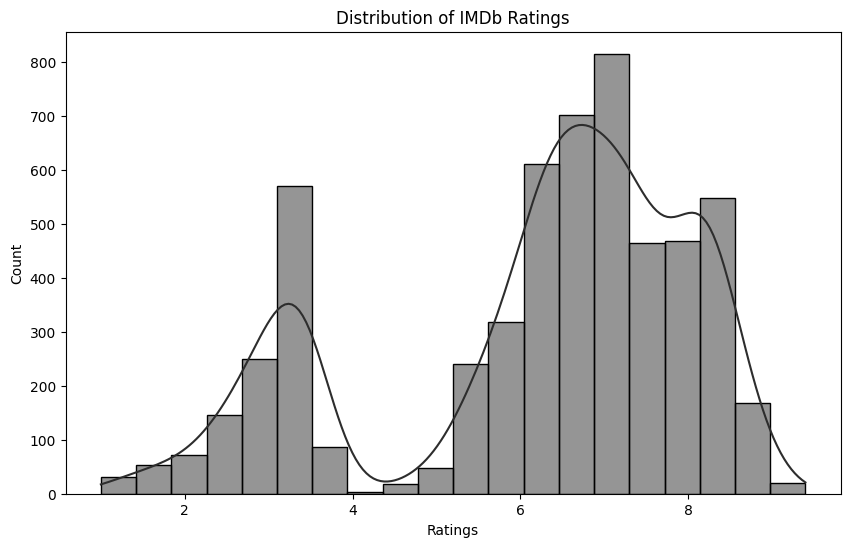

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(df['rating'], bins=20, kde=True, color='#2D2D2D')
plt.title('Distribution of IMDb Ratings')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.savefig("images/ratings_distribution.svg", dpi=300) 
plt.show()

---

## Votes Distribution

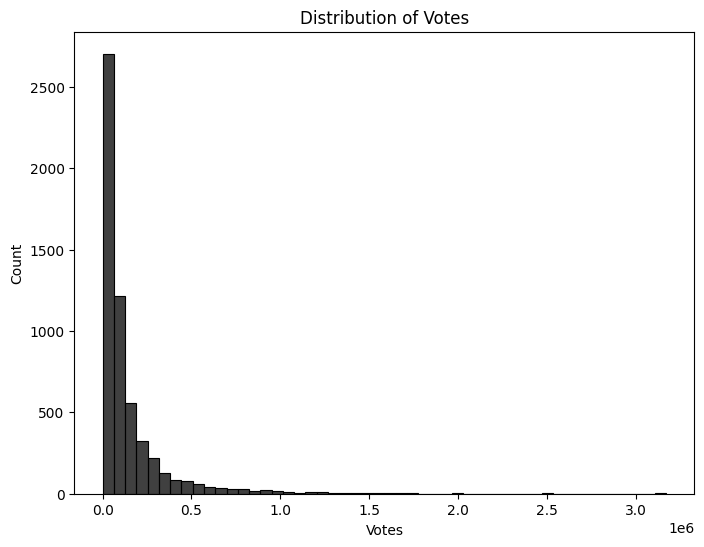

In [8]:
plt.figure(figsize=(8,6))
sns.histplot(df['votes'], bins=50, color='black')
plt.title('Distribution of Votes')
plt.xlabel('Votes')
plt.ylabel('Count')
plt.savefig("images/votes_distribution.svg", dpi=300) 
plt.show()

---

## Movies per year

In [9]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

In [10]:
df['release_year'] = df['release_date'].dt.year

In [11]:
df['release_month'] = df['release_date'].dt.month
df['release_month_name'] = df['release_date'].dt.month_name()

In [12]:
df[['title', 'release_date', 'release_year', 'release_month', 'release_month_name']]

,title,release_date,release_year,release_month,release_month_name
0,Kate & Leopold,2001-12-25,2001,12,December
1,Ko to tamo peva,1980-06-30,1980,6,June
2,Cannibal Holocaust,1985-06-21,1985,6,June
3,Saturn 3,1980-02-15,1980,2,February
4,Moskva slezam ne verit,1980-02-11,1980,2,February
...,...,...,...,...,...
5631,Bandit,2022-09-23,2022,9,September
5632,Holidate,2020-10-28,2020,10,October
5633,Seishun buta yaro wa yumemiru shoujo no yume w...,2019-10-02,2019,10,October
5634,I Care a Lot,2021-02-19,2021,2,February


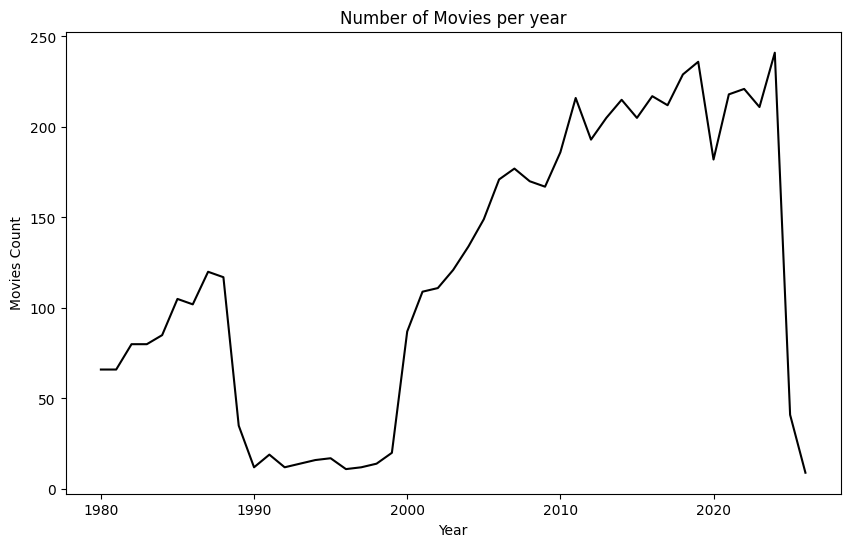

In [13]:
plt.figure(figsize=(10,6))
movies_per_year = df['release_year'].value_counts().sort_index()
plt.plot(movies_per_year, color='black')
plt.title('Number of Movies per year')
plt.xlabel('Year')
plt.ylabel('Movies Count')
plt.savefig("images/movies_per_year.svg", dpi=300) 
plt.show()

---

## Genre Distribution

In [14]:
df['genre_count'] = df['genres'].apply(lambda x: len(x.split("|")))

In [15]:
df[['title', 'genres', 'genre_count']]

,title,genres,genre_count
0,Kate & Leopold,Comedy|Fantasy|Romance,3
1,Ko to tamo peva,Adventure|Comedy|Drama,3
2,Cannibal Holocaust,Adventure|Horror,2
3,Saturn 3,Adventure|Horror|Sci-Fi,3
4,Moskva slezam ne verit,Comedy|Drama|Romance,3
...,...,...,...
5631,Bandit,Biography|Crime|Drama,3
5632,Holidate,Comedy|Romance,2
5633,Seishun buta yaro wa yumemiru shoujo no yume w...,Animation|Drama|Fantasy,3
5634,I Care a Lot,Comedy|Crime|Drama,3


In [16]:
df_genre = df.copy()
df_genre['genres'] = df_genre['genres'].str.split("|")
df_genre = df_genre.explode('genres')

In [17]:
df_genre.head()

,title,genres,description,keywords,release_date,duration,content_rating,director,star_1,star_2,...,budget,movie_url,category,currency_type,gross_usd,budget_usd,release_year,release_month,release_month_name,genre_count
0,Kate & Leopold,Comedy,An English Duke from 1876 is inadvertently dra...,"time travel,time travel romance,female time tr...",2001-12-25,118,PG-13,James Mangold,Meg Ryan,Hugh Jackman,...,"$48,000,000 (estimated)",https://www.imdb.com/title/tt0035423/,Mid Rated,$,76019048.0,48000000.0,2001,12,December,3
0,Kate & Leopold,Fantasy,An English Duke from 1876 is inadvertently dra...,"time travel,time travel romance,female time tr...",2001-12-25,118,PG-13,James Mangold,Meg Ryan,Hugh Jackman,...,"$48,000,000 (estimated)",https://www.imdb.com/title/tt0035423/,Mid Rated,$,76019048.0,48000000.0,2001,12,December,3
0,Kate & Leopold,Romance,An English Duke from 1876 is inadvertently dra...,"time travel,time travel romance,female time tr...",2001-12-25,118,PG-13,James Mangold,Meg Ryan,Hugh Jackman,...,"$48,000,000 (estimated)",https://www.imdb.com/title/tt0035423/,Mid Rated,$,76019048.0,48000000.0,2001,12,December,3
1,Ko to tamo peva,Adventure,"It&apos;s April 5, 1941, somewhere in Serbia. ...","road trip,sex scene,female nudity,year 1941,yu...",1980-06-30,86,Unknown,Slobodan Sijan,Pavle Vuisic,Dragan Nikolic,...,NaN,https://www.imdb.com/title/tt0076276/,Top Rated|Old Movies,NaN,NaN,NaN,1980,6,June,3
1,Ko to tamo peva,Comedy,"It&apos;s April 5, 1941, somewhere in Serbia. ...","road trip,sex scene,female nudity,year 1941,yu...",1980-06-30,86,Unknown,Slobodan Sijan,Pavle Vuisic,Dragan Nikolic,...,NaN,https://www.imdb.com/title/tt0076276/,Top Rated|Old Movies,NaN,NaN,NaN,1980,6,June,3


In [18]:
df_genre['genres'].value_counts()

genres
Drama          2518
Comedy         1768
Action         1644
Adventure      1102
Thriller       1036
Horror          990
Crime           907
Romance         667
Mystery         566
Sci-Fi          530
Fantasy         437
Biography       349
Animation       269
Documentary     250
Family          232
History         185
Music           174
Sport           123
War             101
Musical          87
Western          22
News              7
Unknown           7
Name: count, dtype: int64

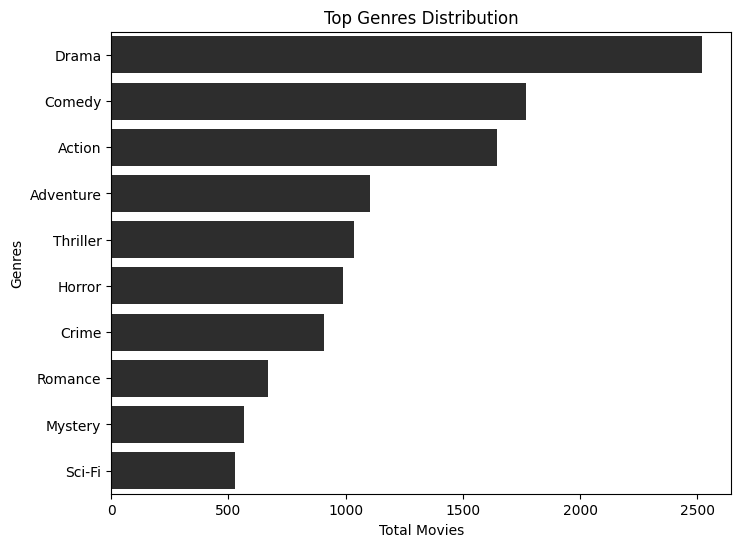

In [19]:
top_genres = df_genre['genres'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_genres.values, y=top_genres.index, color='#2D2D2D')
plt.title("Top Genres Distribution")
plt.xlabel('Total Movies')
plt.ylabel('Genres')
plt.savefig("images/top_genres.svg", dpi=300) 
plt.show()

---

## Rating vs Votes

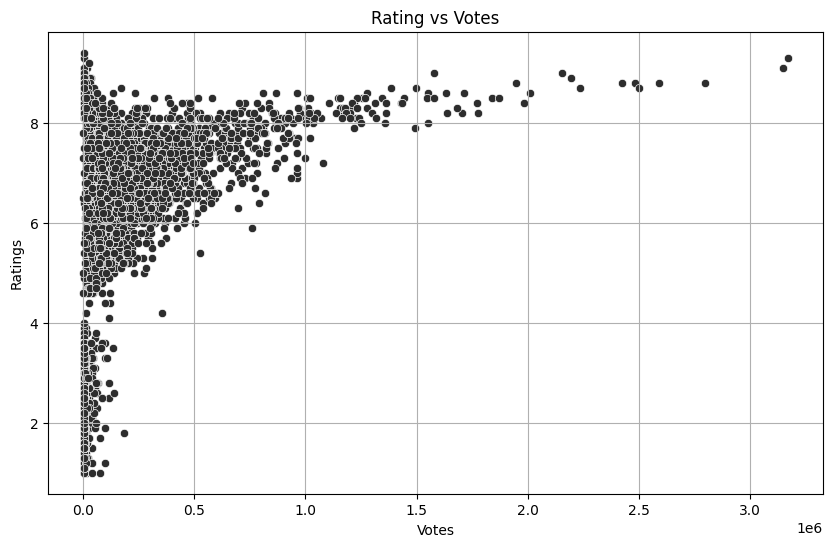

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="votes", y="rating", data=df, color='#2D2D2D')
plt.title("Rating vs Votes")
plt.xlabel("Votes")
plt.ylabel("Ratings")
plt.grid()
plt.savefig("images/rating_vs_votes.svg", dpi=300) 
plt.show()

---

## Average Rating by Genre

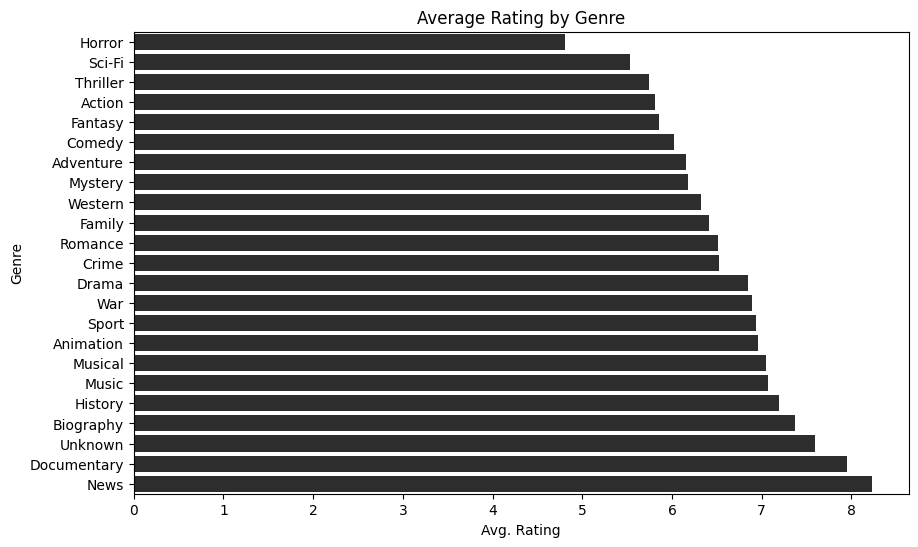

In [21]:
genre_rating = df_genre.groupby('genres')['rating'].mean().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(x=genre_rating.values, y=genre_rating.index, color='#2D2D2D')
plt.title("Average Rating by Genre")
plt.xlabel("Avg. Rating")
plt.ylabel("Genre")
plt.savefig("images/avg_rating_genre.svg", dpi=300) 
plt.show()

---

## Rating Trend over time

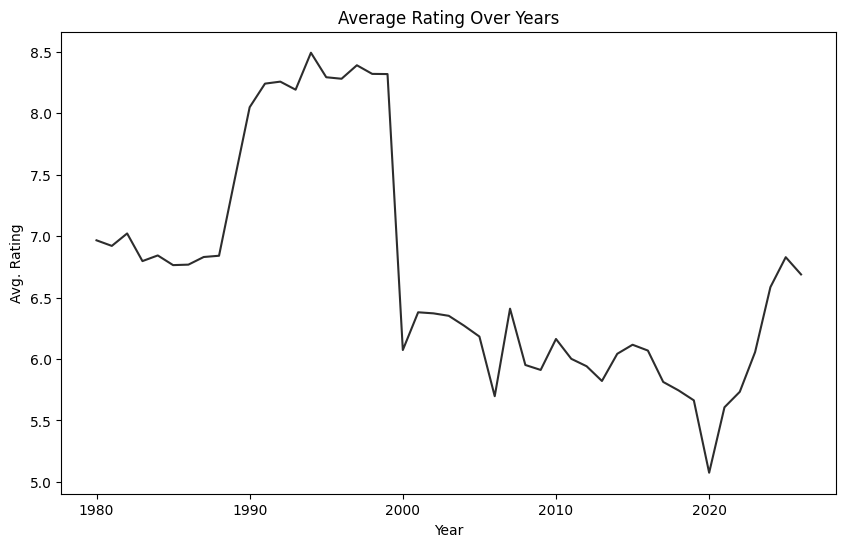

In [22]:
year_rating = df.groupby('release_year')['rating'].mean()

plt.figure(figsize=(10,6))
plt.plot(year_rating, color='#2D2D2D')
plt.title("Average Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Avg. Rating")
plt.savefig("images/rating_trend.svg", dpi=300) 
plt.show()

---

## Budget vs Gross

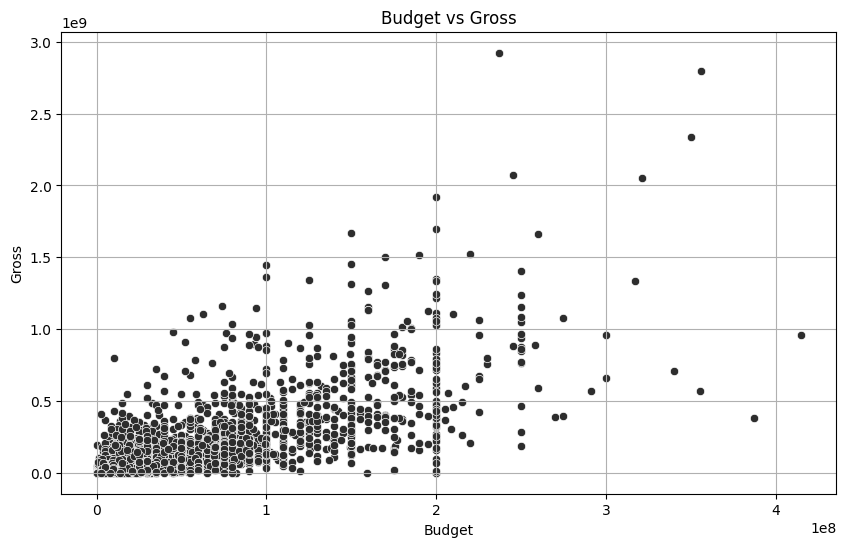

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="budget_usd", y="gross_usd", data=df, color='#2D2D2D')
plt.title("Budget vs Gross")
plt.xlabel("Budget")
plt.ylabel("Gross")
plt.grid()
plt.savefig("images/budget_vs_gross.svg", dpi=300) 
plt.show()

---

## Profit vs Rating

In [24]:
df['profit'] = df['gross_usd'] - df['budget_usd']

In [25]:
df['profit'].isna().sum()

np.int64(2277)

In [26]:
df.dtypes

title                         object
genres                        object
description                   object
keywords                      object
release_date          datetime64[ns]
duration                       int64
content_rating                object
director                      object
star_1                        object
star_2                        object
star_3                        object
countries                     object
languages                     object
rating                       float64
metascore                    float64
votes                          int64
user_reviews                 float64
critic_reviews               float64
watchlist_count              float64
gross                         object
budget                        object
movie_url                     object
category                      object
currency_type                 object
gross_usd                    float64
budget_usd                   float64
release_year                   int32
r

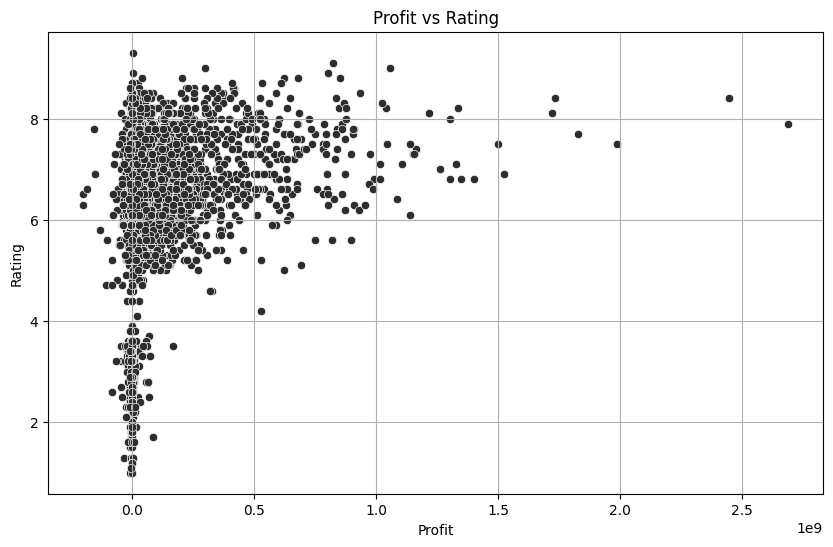

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="profit", y="rating", data=df, color='#2D2D2D')
plt.title("Profit vs Rating")
plt.xlabel("Profit")
plt.ylabel("Rating")
plt.grid()
plt.savefig("images/profit_vs_rating.svg", dpi=300) 
plt.show()

---

## Correlation Matrix

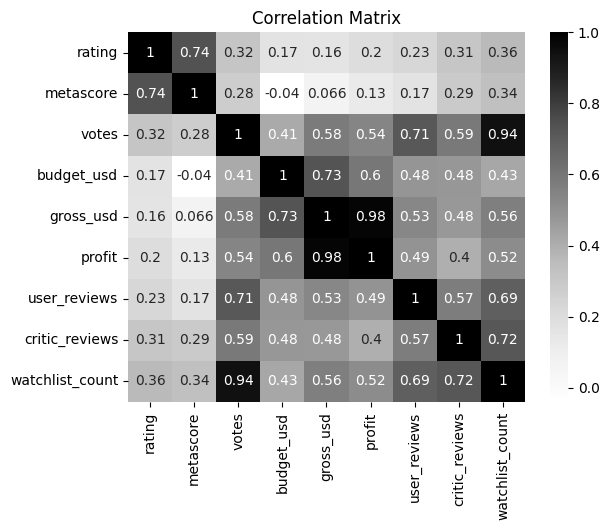

In [28]:
corr = df[["rating", "metascore", "votes", "budget_usd", "gross_usd", "profit", "user_reviews", "critic_reviews", "watchlist_count"]].corr()

sns.heatmap(corr, annot=True, cmap='Greys')
plt.title("Correlation Matrix")
plt.savefig("images/correlation_heatmap.svg", dpi=300) 
plt.show()

---

## Genre vs Popularity (Votes) vs Rating

In [28]:
df_genre.groupby("genres").agg({
    "rating": "mean",
    "votes": "mean"
}).sort_values(by="votes", ascending=False).head(10)

,rating,votes
genres,,
Adventure,6.158024,227959.444243
Sci-Fi,5.527119,227287.994350
Western,6.327273,221379.681818
Animation,6.963333,208043.270370
Fantasy,5.863927,187732.694064
Action,5.807547,180378.248935
Crime,6.524476,165163.082690
Biography,7.367622,156352.048711
War,6.892079,154812.851485


---

## Movie by Category

In [29]:
df_category = df.copy()
df_category['Scrape_Category'] = df_category['Scrape_Category'].str.split("|")
df_category = df_category.explode('Scrape_Category')

In [30]:
df_category.head()

,title,genres,release_date,duration,rating,votes,content_rating,star_1,star_2,star_3,...,movie_url,Scrape_Category,currency_type,gross_usd,budget_usd,release_year,release_month,release_month_name,genre_count,profit
0,Kate & Leopold,Comedy|Fantasy|Romance,2001-12-25,118,6.4,93696,PG-13,Meg Ryan,Hugh Jackman,Liev Schreiber,...,https://www.imdb.com/title/tt0035423/,Mid Rated,$,76019048.0,48000000.0,2001,12,December,3,28019048.0
1,Ko to tamo peva,Adventure|Comedy|Drama,1980-06-30,86,8.7,17858,Unknown,Pavle Vuisic,Dragan Nikolic,Danilo 'Bata' Stojkovic,...,https://www.imdb.com/title/tt0076276/,Old Movies,NaN,NaN,NaN,1980,6,June,3,NaN
1,Ko to tamo peva,Adventure|Comedy|Drama,1980-06-30,86,8.7,17858,Unknown,Pavle Vuisic,Dragan Nikolic,Danilo 'Bata' Stojkovic,...,https://www.imdb.com/title/tt0076276/,Top Rated,NaN,NaN,NaN,1980,6,June,3,NaN
2,Cannibal Holocaust,Adventure|Horror,1985-06-21,95,5.8,66571,Unrated,Robert Kerman,Francesca Ciardi,Perry Pirkanen,...,https://www.imdb.com/title/tt0078935/,Old Movies,$,477.0,100000.0,1985,6,June,2,-99523.0
3,Saturn 3,Adventure|Horror|Sci-Fi,1980-02-15,88,5.1,11529,R,Farrah Fawcett,Kirk Douglas,Harvey Keitel,...,https://www.imdb.com/title/tt0079285/,Old Movies,£,9000000.0,12500000.0,1980,2,February,3,-3500000.0


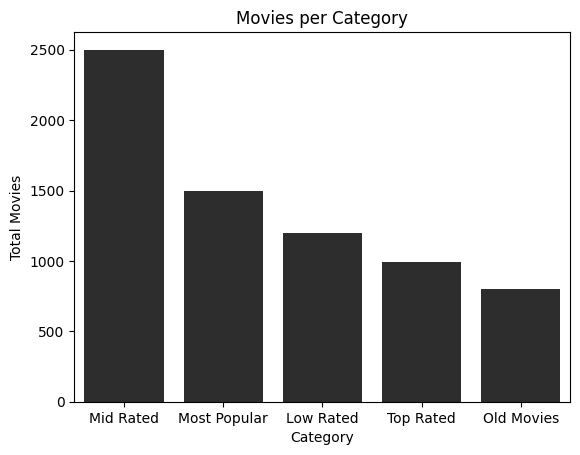

In [31]:
category_count = df_category['Scrape_Category'].value_counts()

sns.barplot(x=category_count.index, y=category_count.values, color='#2D2D2D')
    
plt.title("Movies per Category")
plt.xlabel("Category")
plt.ylabel("Total Movies")
plt.savefig("images/movies_per_category.png", dpi=300) 
plt.show()

---

## Rating and Votes by Category

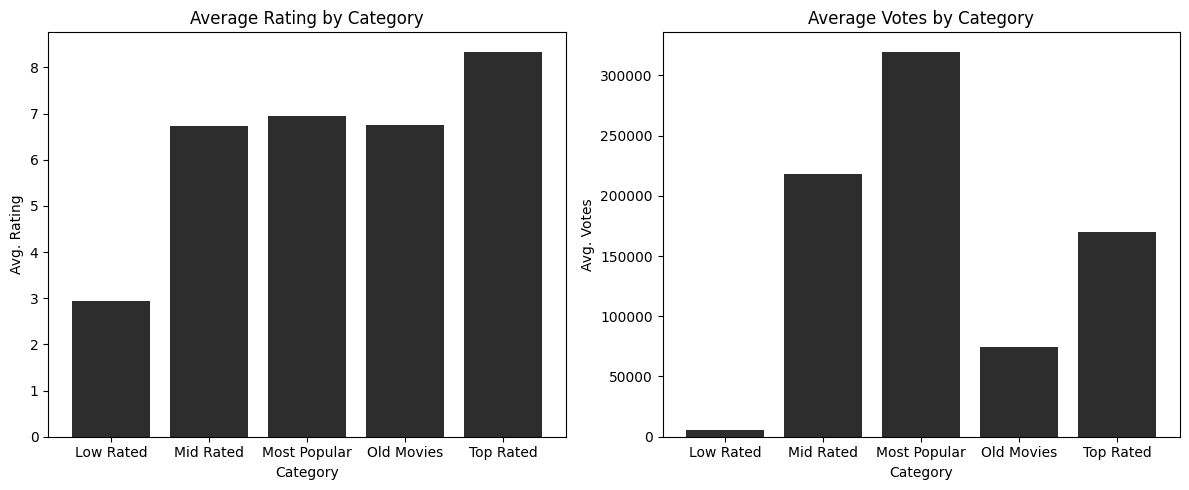

In [32]:
cat_rating = df_category.groupby('Scrape_Category')['rating'].mean()
cat_votes = df_category.groupby('Scrape_Category')['votes'].mean()

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))

ax1.bar(cat_rating.index, cat_rating.values, color='#2D2D2D')
ax1.set_title("Average Rating by Category")
ax1.set_xlabel("Category")
ax1.set_ylabel("Avg. Rating")

ax2.bar(cat_votes.index, cat_votes.values, color='#2D2D2D')
ax2.set_title("Average Votes by Category")
ax2.set_xlabel("Category")
ax2.set_ylabel("Avg. Votes")

plt.tight_layout()
plt.savefig("images/Rating_Votes_Cat.svg", dpi=300) 
plt.show()

---

## Category Count Impact

In [33]:
df['category_count'] = df["Scrape_Category"].apply(lambda x: len(x.split("|")))

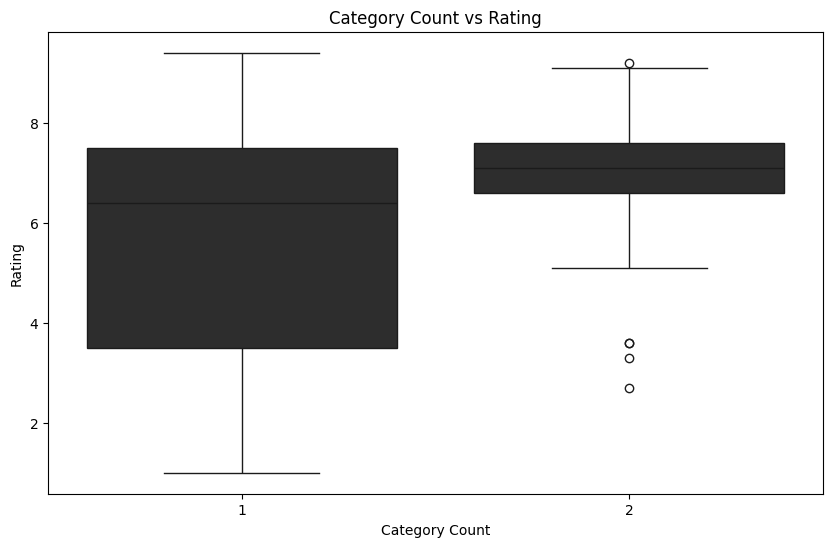

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x="category_count", y="rating", data=df, color='#2D2D2D')
plt.title("Category Count vs Rating")
plt.xlabel("Category Count")
plt.ylabel("Rating")
plt.savefig("images/category_count_impact.svg", dpi=300) 
plt.show()

---